In [1]:
# ==============================================================
import numpy as np
import warnings

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.feature import ShapelyFeature
import cartopy.io.shapereader as shpreader


import sys
sys.path.append("/home/nchoi21/utils/python/nbchoi")
import f_nchoi as nb

import colormaps as cmaps
import matplotlib as mpl
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from scipy import signal

import os 
import glob
import subprocess
import regionmask

import pandas as pd
import xarray as xr
warnings.filterwarnings("ignore", category=UserWarning)
# ==============================================================

In [2]:
## OPEN Precip
mod = xr.open_dataset('/scratch/nchoi21/CMIP/HighResMIP/climate/Regrid_25yrs_clim_temp.nc').t[:,0:5,:,:,:].mean('time')
print(mod)
lsm = regionmask.defined_regions.natural_earth_v5_0_0.land_110  # 110m resolution
mask = lsm.mask(mod.coords['longitude'], mod.coords['latitude'])
ocean_mask = xr.where(mask.isnull(), 1, 0)
mod = mod.where(ocean_mask == 1)


pr = mod[1:]-mod[0]
print(pr)

<xarray.DataArray 't' (model: 10, level: 6, latitude: 181, longitude: 360)> Size: 31MB
array([[[[251.26051941, 251.26051941, 251.26051941, ..., 251.26051941,
          251.26051941, 251.26051941],
         [250.79320984, 250.79544067, 250.79782715, ..., 250.78580627,
          250.78836365, 250.79085083],
         [251.14191589, 251.18662109, 251.22999573, ..., 251.02540283,
          251.05920715, 251.0986908 ],
         ...,
         [252.66459045, 252.67291565, 252.68038635, ..., 252.63631592,
          252.64593811, 252.6553833 ],
         [252.36629944, 252.36732788, 252.36865234, ..., 252.36393127,
          252.36473999, 252.36550293],
         [252.06648865, 252.06648865, 252.06648865, ..., 252.06648865,
          252.06648865, 252.06648865]],

        [[247.58285522, 247.58285522, 247.58285522, ..., 247.58285522,
          247.58285522, 247.58285522],
         [247.09376831, 247.09501953, 247.09632874, ..., 247.09011841,
          247.0914032 , 247.09258118],
         [247.433

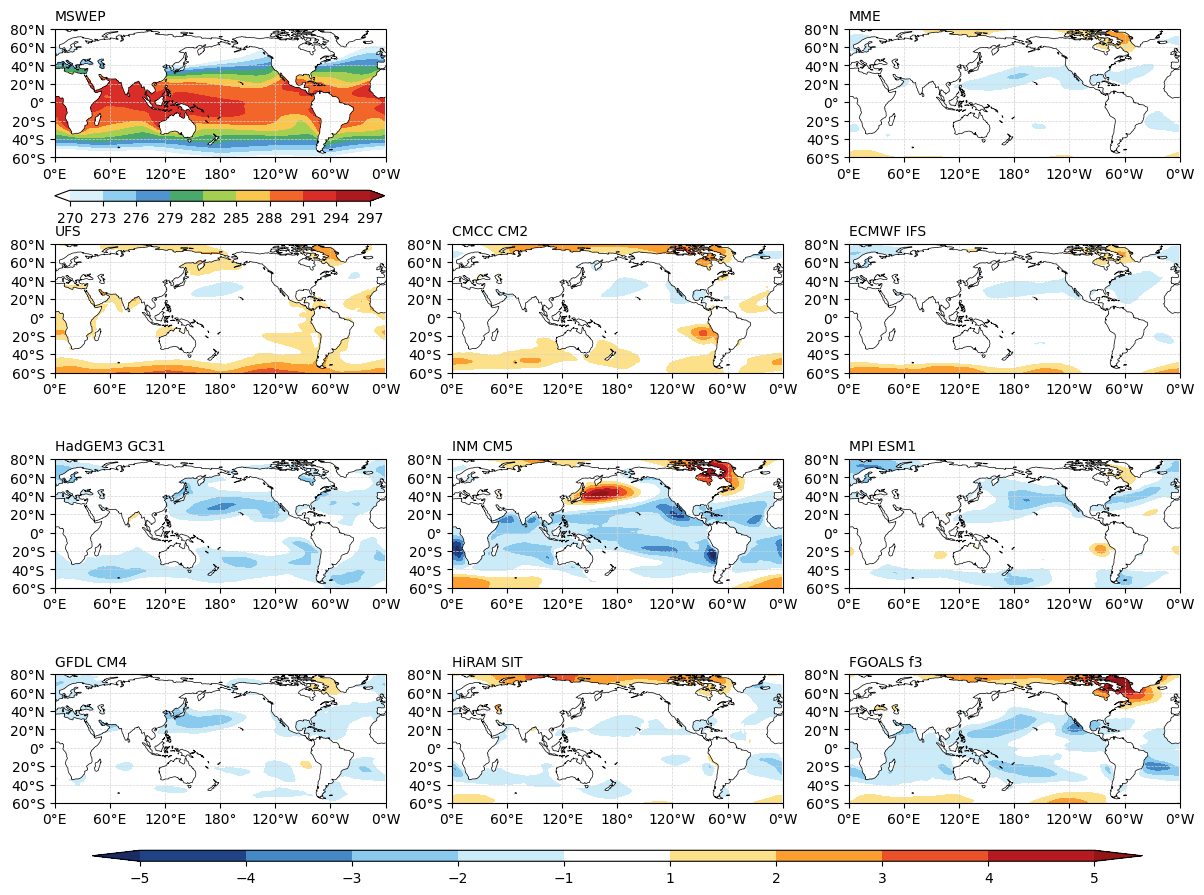

In [3]:
mod = mod.sel(level=850)

fig = plt.figure(figsize=(15,11))
plt.subplots_adjust(bottom=0.2,top=0.95,left=0.05,right=0.8)
model = ['MSWEP','UFS','CMCC CM2','ECMWF IFS','HadGEM3 GC31','INM CM5','MPI ESM1','GFDL CM4','HiRAM SIT','FGOALS f3']
projection = ccrs.PlateCarree(central_longitude=180.0)
lon_tick = np.arange(-180,181,60) ## Add 1 in end-point
lat_tick = np.arange(-60,81,20)
lon_formatter = LongitudeFormatter(zero_direction_label = True)
lat_formatter = LatitudeFormatter()
plt.set_cmap(cmaps.WhiteBlueGreenYellowRed)   # color map
#clevs = [-3,-2.5,-2,-1.5,-1.0,-0.5,0.5,1.0,1.5,2.0,2.5,3]

clevs = np.arange(270,300,3)
plt.subplot(431,projection=projection)
longitude = mod['longitude']
latitude = mod['latitude']
longitude = longitude - 180
a=plt.contourf(longitude,latitude,mod[0,:,:],levels=clevs,extend='both')
plt.gca().set_yticks(lat_tick,crs=projection)
plt.gca().set_xticks(lon_tick,crs=projection)
plt.gca().xaxis.set_major_formatter(lon_formatter)
plt.gca().yaxis.set_major_formatter(lat_formatter)
plt.gca().set_extent([-180, 180, -60, 80], crs=projection)
plt.gca().gridlines(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
#plt.gca().add_feature(cfeature.LAND,linewidth=0.5,edgecolor='black',facecolor='white',zorder=2)
plt.gca().coastlines(linewidth=0.5, edgecolor='black',zorder=3)  # Draw Coastline
#plt.gca().add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black',zorder=3)
plt.gca().set_title('MSWEP',loc='left',fontsize=10)
cax = plt.axes([0.05,0.77,0.22,0.01]) # Left, Bottom, width, height
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')

clevs = np.arange(-5,6,1)
clevs = clevs[clevs!=0]

plt.subplot(4,3,3,projection=projection)
a=plt.contourf(longitude,latitude,mod[1:,:,:].mean('model') - mod[0,:,:],levels=clevs,extend='both')
plt.gca().set_yticks(lat_tick,crs=projection)
plt.gca().set_xticks(lon_tick,crs=projection)
plt.gca().xaxis.set_major_formatter(lon_formatter)
plt.gca().yaxis.set_major_formatter(lat_formatter)
plt.gca().set_extent([-180, 180, -60, 80], crs=projection)
plt.gca().gridlines(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
plt.gca().coastlines(linewidth=0.5, edgecolor='black',zorder=3)  # Draw Coastline
plt.gca().set_title('MME',loc='left',fontsize=10)
plt.set_cmap(cmaps.BlueWhiteOrangeRed)

for n in range(0,9):
    plt.subplot(4,3,4+n,projection=projection)
    a=plt.contourf(longitude,latitude,mod[n+1,:,:] - mod[0,:,:],levels=clevs,extend='both')
    plt.gca().set_yticks(lat_tick,crs=projection)
    plt.gca().set_xticks(lon_tick,crs=projection)
    plt.gca().xaxis.set_major_formatter(lon_formatter)
    plt.gca().yaxis.set_major_formatter(lat_formatter)
    plt.gca().set_extent([-180, 180, -60, 80], crs=projection)
    plt.gca().gridlines(color='lightgray',linestyle='--',linewidth =0.5,zorder=3)
    plt.gca().coastlines(linewidth=0.5, edgecolor='black',zorder=3)  # Draw Coastline
    plt.gca().set_title(model[n+1],loc='left',fontsize=10)
    plt.set_cmap(cmaps.BlueWhiteOrangeRed)   # color map
    
cax = plt.axes([0.075,0.17,0.7,0.01]) # Left, Bottom, width, height
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')

In [4]:
## OPEN Precip
mod = xr.open_dataset('/scratch/nchoi21/CMIP/HighResMIP/climate/Regrid_25yrs_clim_temp.nc').t[:,0:5,:,:,:].mean('time')
lsm = regionmask.defined_regions.natural_earth_v5_0_0.land_110  # 110m resolution
mask = lsm.mask(mod.coords['longitude'], mod.coords['latitude'])
ocean_mask = xr.where(mask.isnull(), 1, 0)
mod = mod.where(ocean_mask == 1)

mod_anom = mod - mod.sel(latitude=slice(-20,20)).mean('latitude')



pr = mod_anom[1:]-mod_anom[0]
#pr = pr.sel(longitude=slice('210','271')).mean('longitude')
pr = pr.mean('longitude')

<xarray.DataArray 't' (model: 10, level: 6, latitude: 181, longitude: 61)> Size: 5MB
array([[[[         nan,          nan,          nan, ...,          nan,
                   nan,          nan],
         [         nan,          nan,          nan, ...,          nan,
                   nan,          nan],
         [         nan,          nan,          nan, ...,          nan,
                   nan,          nan],
         ...,
         [-46.30369203, -46.27924552, -46.24962917, ..., -45.38524426,
          -45.31390834, -45.25759026],
         [-46.16755006, -46.14149832, -46.11111599, ..., -45.18336437,
          -45.11396938, -45.05881096],
         [-45.92413576, -45.89644827, -45.8643417 , ..., -45.03620251,
          -44.97043605, -44.91874138]],

        [[         nan,          nan,          nan, ...,          nan,
                   nan,          nan],
         [         nan,          nan,          nan, ...,          nan,
                   nan,          nan],
         [         

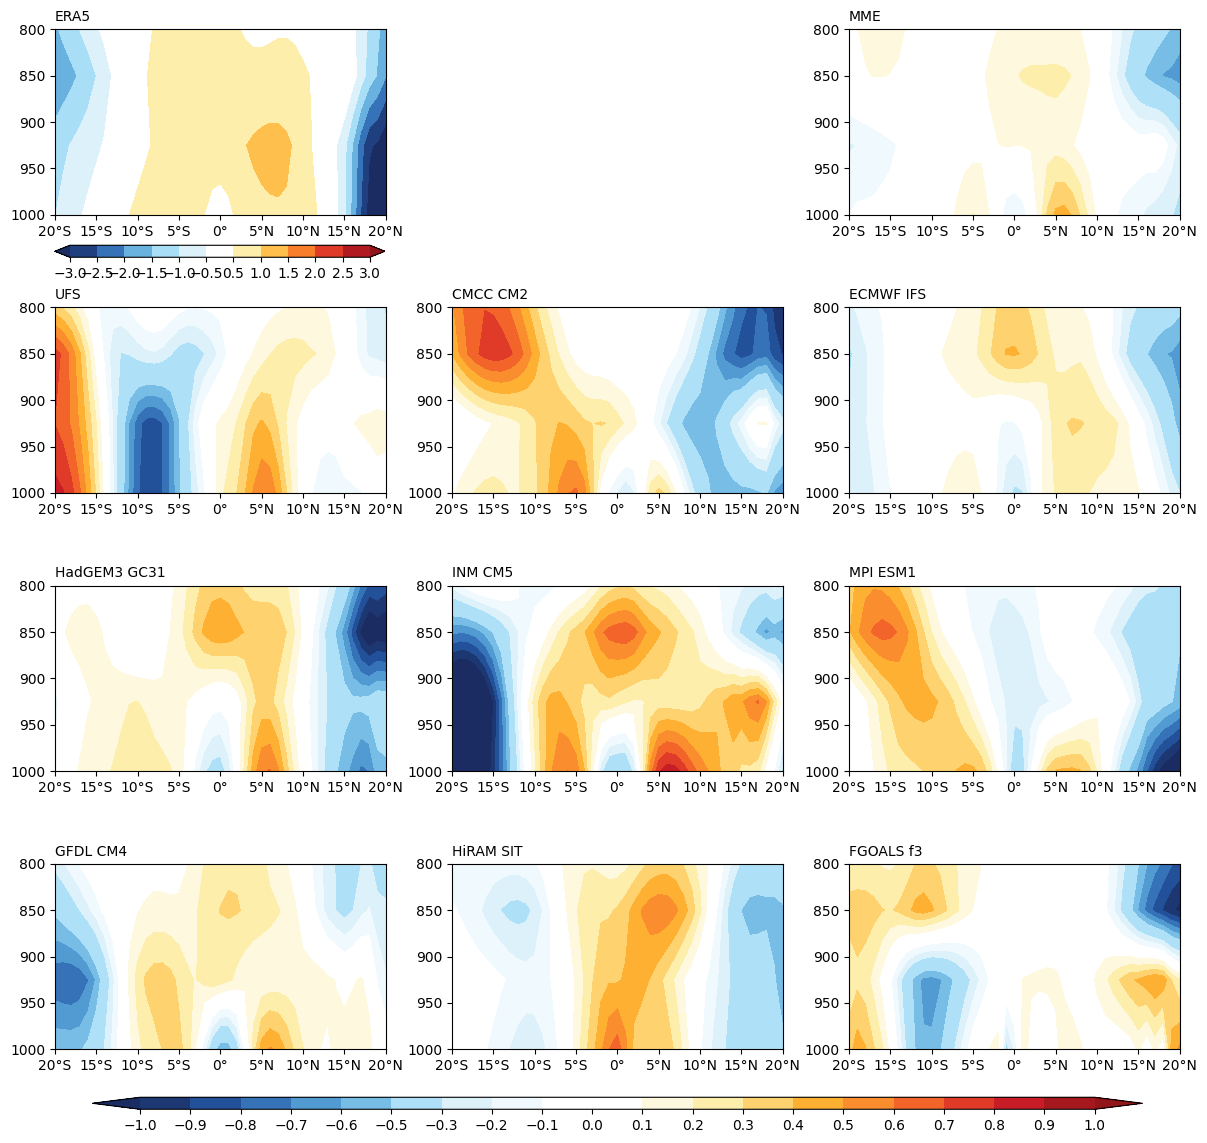

In [5]:
## PLOT Weekly Bias
mod = mod_anom.sel(longitude=slice('210','271'))
print(mod)
fig = plt.figure(figsize=(15,12))
plt.subplots_adjust(bottom=0.1,top=0.95,left=0.05,right=0.8)
model = ['ERA5','UFS','CMCC CM2','ECMWF IFS','HadGEM3 GC31','INM CM5','MPI ESM1','GFDL CM4','HiRAM SIT','FGOALS f3']
projection = ccrs.PlateCarree(central_longitude=180.0)
lon_tick = np.arange(-180,181,60) ## Add 1 in end-point
lat_tick = np.arange(-60,81,5)
lon_formatter = LongitudeFormatter(zero_direction_label = True)
lat_formatter = LatitudeFormatter()
#plt.set_cmap(cmaps.WhiteBlueGreenYellowRed)
plt.set_cmap(cmaps.BlueWhiteOrangeRed)# color map
#clevs = [-3,-2.5,-2,-1.5,-1.0,-0.5,0.5,1.0,1.5,2.0,2.5,3]

clevs = np.arange(270,305,3)
clevs = np.arange(-3,3.1,0.5)
clevs = clevs[clevs!=clevs[6]]
plt.subplot(431)
lev = mod['level']
latitude = mod['latitude']
a=plt.contourf(latitude,lev,mod[0,:,:].mean('longitude'),levels=clevs,extend='both')
plt.gca().set_xticks(lat_tick)
plt.gca().xaxis.set_major_formatter(lat_formatter)
plt.gca().set_title('ERA5',loc='left',fontsize=10)
plt.gca().invert_yaxis()
plt.xlim(-20, 20)
plt.ylim(1000,800)
cax = plt.axes([0.05,0.76,0.22,0.01]) # Left, Bottom, width, height
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')

clevs = np.arange(-1,1.1,0.1)
clevs = clevs[clevs!=clevs[6]]

plt.subplot(4,3,3)
a=plt.contourf(latitude,lev,mod[1:,:,:].mean(('model','longitude')) - mod[0,:,:].mean('longitude'),levels=clevs,extend='both')
#a=plt.contourf(latitude,lev,mod[1:,:,:].mean(('model','longitude')),levels=clevs,extend='both')
plt.gca().set_xticks(lat_tick)
plt.gca().xaxis.set_major_formatter(lat_formatter)
plt.gca().set_title('ERA5',loc='left',fontsize=10)
plt.gca().invert_yaxis()
plt.gca().set_title('MME',loc='left',fontsize=10)
plt.xlim(-20, 20)
plt.ylim(1000,800)
plt.set_cmap(cmaps.BlueWhiteOrangeRed)

for n in range(0,9):
    plt.subplot(4,3,4+n)
    a=plt.contourf(latitude,lev,mod[n+1,:,:].mean('longitude') - mod[0,:,:].mean('longitude'),levels=clevs,extend='both')
    #a=plt.contourf(latitude,lev,mod[n+1,:,:].mean('longitude'),levels=clevs,extend='both')
    plt.gca().set_xticks(lat_tick)
    plt.gca().xaxis.set_major_formatter(lat_formatter)
    plt.gca().set_title('MSWEP',loc='left',fontsize=10)
    plt.gca().invert_yaxis()
    plt.gca().set_title(model[n+1],loc='left',fontsize=10)
    plt.xlim(-20, 20)
    plt.ylim(1000,800)
    plt.set_cmap(cmaps.BlueWhiteOrangeRed)   # color map
    
cax = plt.axes([0.075,0.05,0.7,0.01]) # Left, Bottom, width, height
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')
plt.subplots_adjust(hspace=0.5)

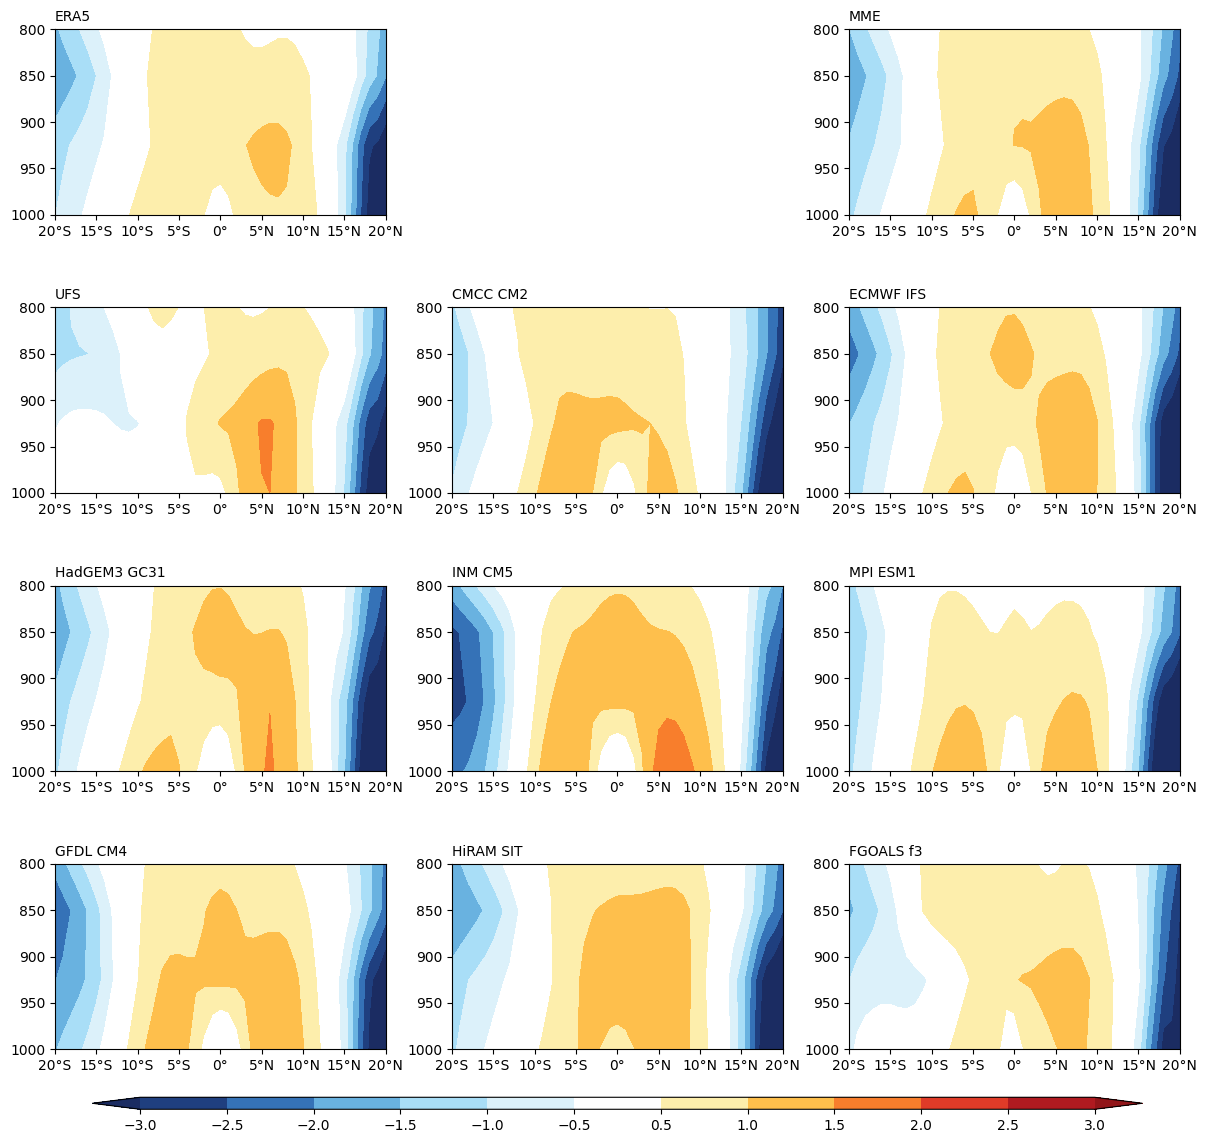

In [6]:
## PLOT Weekly Bias
mod = mod_anom.sel(longitude=slice('210','271'))
fig = plt.figure(figsize=(15,12))
plt.subplots_adjust(bottom=0.1,top=0.95,left=0.05,right=0.8)
model = ['ERA5','UFS','CMCC CM2','ECMWF IFS','HadGEM3 GC31','INM CM5','MPI ESM1','GFDL CM4','HiRAM SIT','FGOALS f3']
projection = ccrs.PlateCarree(central_longitude=180.0)
lon_tick = np.arange(-180,181,60) ## Add 1 in end-point
lat_tick = np.arange(-60,81,5)
lon_formatter = LongitudeFormatter(zero_direction_label = True)
lat_formatter = LatitudeFormatter()
#plt.set_cmap(cmaps.WhiteBlueGreenYellowRed)
plt.set_cmap(cmaps.BlueWhiteOrangeRed)# color map
#clevs = [-3,-2.5,-2,-1.5,-1.0,-0.5,0.5,1.0,1.5,2.0,2.5,3]

clevs = np.arange(270,305,3)
clevs = np.arange(-3,3.1,0.5)
clevs = clevs[clevs!=clevs[6]]
plt.subplot(431)
lev = mod['level']
latitude = mod['latitude']
a=plt.contourf(latitude,lev,mod[0,:,:].mean('longitude'),levels=clevs,extend='both')
plt.gca().set_xticks(lat_tick)
plt.gca().xaxis.set_major_formatter(lat_formatter)
plt.gca().set_title('ERA5',loc='left',fontsize=10)
plt.gca().invert_yaxis()
plt.xlim(-20, 20)
plt.ylim(1000,800)
#cax = plt.axes([0.05,0.76,0.22,0.01]) # Left, Bottom, width, height
#cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')

clevs = np.arange(-3,3.1,0.5)
clevs = clevs[clevs!=clevs[6]]

plt.subplot(4,3,3)
#a=plt.contourf(latitude,lev,mod[1:,:,:].mean(('model','longitude')) - mod[0,:,:].mean('longitude'),levels=clevs,extend='both')
a=plt.contourf(latitude,lev,mod[1:,:,:].mean(('model','longitude')),levels=clevs,extend='both')
plt.gca().set_xticks(lat_tick)
plt.gca().xaxis.set_major_formatter(lat_formatter)
plt.gca().set_title('MSWEP',loc='left',fontsize=10)
plt.gca().invert_yaxis()
plt.gca().set_title('MME',loc='left',fontsize=10)
plt.xlim(-20, 20)
plt.ylim(1000,800)
plt.set_cmap(cmaps.BlueWhiteOrangeRed)

for n in range(0,9):
    plt.subplot(4,3,4+n)
    #a=plt.contourf(latitude,lev,mod[n,:,:].mean('longitude') - mod[0,:,:].mean('longitude'),levels=clevs,extend='both')
    a=plt.contourf(latitude,lev,mod[n+1,:,:].mean('longitude'),levels=clevs,extend='both')
    plt.gca().set_xticks(lat_tick)
    plt.gca().xaxis.set_major_formatter(lat_formatter)
    plt.gca().set_title('MSWEP',loc='left',fontsize=10)
    plt.gca().invert_yaxis()
    plt.gca().set_title(model[n+1],loc='left',fontsize=10)
    plt.xlim(-20, 20)
    plt.ylim(1000,800)
    plt.set_cmap(cmaps.BlueWhiteOrangeRed)   # color map
    
cax = plt.axes([0.075,0.05,0.7,0.01]) # Left, Bottom, width, height
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')
plt.subplots_adjust(hspace=0.5)

In [7]:
pc = xr.open_dataset('DITCZ_index.nc').pcs[:,0]
print(pc.coords['time'])
print(pr)

<xarray.DataArray 'time' (time: 9)> Size: 540B
array(['UFS-P8-V16', 'CMCC-CM2-VHR4', 'ECMWF-IFS-HR', 'HadGEM3-GC31-HM',
       'INM-CM5-H', 'MPI-ESM1-2-XR', 'GFDL-CM4C192', 'HiRAM-SIT-HR',
       'FGOALS-f3-H'], dtype='<U15')
Coordinates:
  * time     (time) <U15 540B 'UFS-P8-V16' 'CMCC-CM2-VHR4' ... 'FGOALS-f3-H'
    mode     int64 8B 0
<xarray.DataArray 't' (model: 9, level: 6, latitude: 181)> Size: 78kB
array([[[        nan,         nan,         nan, ...,  0.52810267,
          0.57841128,         nan],
        [        nan,         nan,         nan, ...,  1.69752951,
          1.68323375,         nan],
        [        nan,         nan,         nan, ...,  0.16875772,
          0.16216344,         nan],
        [        nan,         nan,         nan, ..., -0.41479184,
         -0.42045243,         nan],
        [        nan,         nan,         nan, ..., -0.4194733 ,
         -0.41808946,         nan],
        [        nan,         nan,         nan, ..., -0.33395655,
         -0.34

In [8]:
import numpy as np
import xarray as xr
import dask.array as da
from scipy.stats import linregress

def reg(index: xr.DataArray, data: xr.DataArray) -> tuple[xr.DataArray, xr.DataArray]:
    """
    Dask를 활용하여 3D 데이터 (data)와 1D 인덱스 (index) 간 선형 회귀 분석을 병렬 처리하는 함수.

    매개변수:
    - index: xarray DataArray of shape (model,), 회귀분석의 독립변수
    - data: xarray DataArray of shape (model, latitude, longitude), 분석할 데이터

    반환값:
    - (latitude, longitude) 차원의 xarray DataArray, 회귀계수(기울기)와 p-value
    """

    # 인덱스와 데이터 값을 Dask 배열로 변환
    X = da.from_array(index.values, chunks=(index.sizes['time'],))
    Y = da.from_array(data.values, chunks=(data.sizes['model'], data.sizes['level'],data.sizes['latitude']))

    # 회귀 분석 수행 (Dask map_blocks 사용)
    def lin_regression(y, X):
        """ 단일 (lat, lon) 위치에서 선형 회귀 수행 및 p-value 계산 """
        if np.all(np.isnan(y)):  # 모든 값이 NaN이면 NaN 반환
            return np.nan, np.nan
        valid_mask = np.isfinite(y)  # NaN이 없는 값만 선택
        if np.sum(valid_mask) < 2:  # 최소 2개 이상의 유효한 데이터 필요
            return np.nan, np.nan
        
        # 회귀분석 수행
        slope, intercept, r_value, p_value, std_err = linregress(X[valid_mask], y[valid_mask])
        
        return slope, p_value  # 기울기와 p-value 반환

    # 병렬 연산 수행
    regression_results = da.apply_along_axis(lin_regression, 0, Y, X)

    # 결과 분리 (slope, p-value)
    slope_result = regression_results[0].compute()
    p_value_result = regression_results[1].compute()

    # 결과를 xarray DataArray로 변환
    regression = xr.DataArray(
        slope_result,
        dims=['level','latitude'],
        coords={'latitude': data.coords['latitude'],
                'level': data.coords['level']},
        name="Regression"
    )

    p_value = xr.DataArray(
        p_value_result,
        dims=['level','latitude'],
        coords={'latitude': data.coords['latitude'],
                'level': data.coords['level']},
        name="P-value"
    )

    return regression, p_value


In [9]:
pr_regres, pr_p = reg(pc,pr)

In [10]:
#pr_regres = xr.where(pr_p <= 0.05, pr_regres, np.nan)
#sst_regres = xr.where(sst_p <= 0.05, sst_regres, np.nan)
pr_p = xr.where(pr_p <= 0.05, pr_p, np.nan)

<xarray.DataArray 'Regression' (latitude: 181, longitude: 360)> Size: 521kB
[65160 values with dtype=float64]
Coordinates:
  * latitude   (latitude) int64 1kB -90 -89 -88 -87 -86 -85 ... 86 87 88 89 90
  * longitude  (longitude) int64 3kB 0 1 2 3 4 5 6 ... 354 355 356 357 358 359


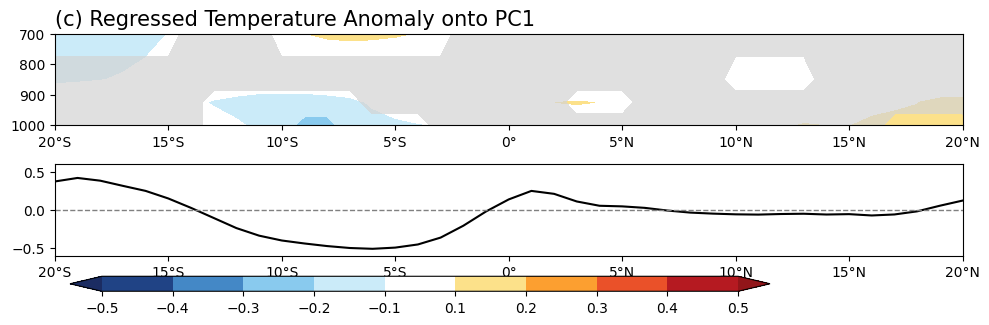

In [11]:
fig = plt.figure(figsize=(10,3))
plt.subplots_adjust(bottom=0.2,top=0.95,left=0.05,right=0.8)
lat_tick = np.arange(-60,81,5)
lon_formatter = LongitudeFormatter(zero_direction_label = True)
lat_formatter = LatitudeFormatter()
#plt.set_cmap(cmaps.WhiteBlueGreenYellowRed)
plt.set_cmap(cmaps.BlueWhiteOrangeRed)# color map
#clevs = [-3,-2.5,-2,-1.5,-1.0,-0.5,0.5,1.0,1.5,2.0,2.5,3]

sst = xr.open_dataset('sst_regres.nc').Regression
print(sst)

clevs = np.arange(270,305,3)
clevs = np.arange(-0.5,0.6,0.1)
clevs = clevs[clevs!=clevs[5]]
plt.subplot(211)
lev = mod['level']
latitude = mod['latitude']
b=plt.contourf(latitude,lev, np.isnan(pr_p), colors='lightgray', alpha=0.7,levels=[0.5, 1.5], zorder=2)
a=plt.contourf(latitude,lev,pr_regres,levels=clevs,extend='both')
plt.gca().set_xticks(lat_tick)
plt.gca().xaxis.set_major_formatter(lat_formatter)
plt.gca().set_title('(c) Regressed Temperature Anomaly onto PC1',loc='left',fontsize=15)
plt.gca().invert_yaxis()
plt.xlim(-20, 20)
plt.ylim(1000,700)

plt.subplot(212)
lat_tick = np.arange(-60,81,5)
lat_formatter = LatitudeFormatter()

a=plt.plot(latitude,sst.sel(longitude=slice(210,270)).mean('longitude'),color='k')
plt.gca().set_xticks(lat_tick)
plt.gca().xaxis.set_major_formatter(lat_formatter)
plt.xlim(-20,20)
plt.ylim(-0.6,0.6)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)


cax = plt.axes([0.075,0.01,0.7,0.05]) # Left, Bottom, width, height
cb = plt.colorbar(cax=cax,orientation='horizontal',ticks=clevs,extend='both')
#ticks = cb.get_ticks()[::2]  # 기존 눈금에서 2칸마다 선택
#cb.set_ticks(ticks)
#cb.set_ticks((-1,-0.8,-0.6,-0.4,-0.2,0.2,0.4,0.6,0.8,1))
plt.tight_layout()
plt.savefig('fig3d.png', dpi=1000)

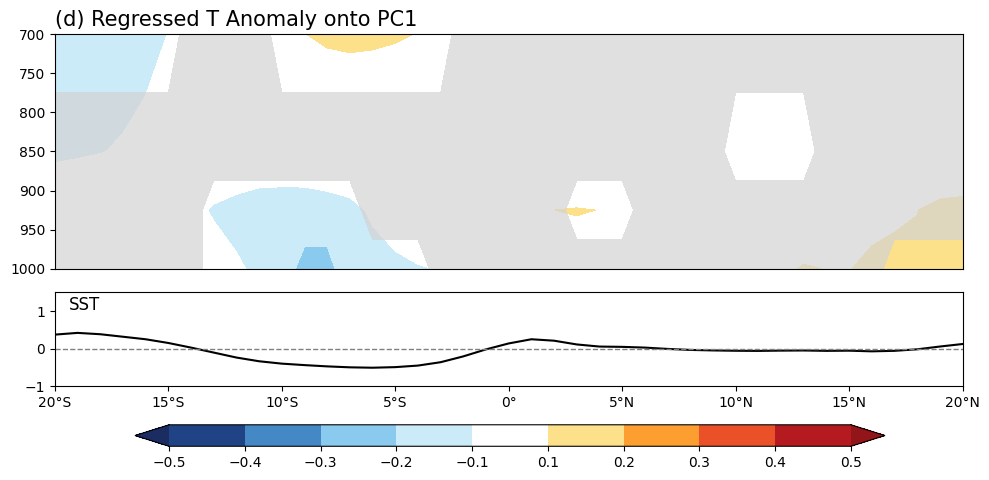

In [14]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2, 
    figsize=(10, 4.3), 
    gridspec_kw={'height_ratios': [1., 0.4]}, 
    sharex=True
)

plt.subplots_adjust(bottom=0.2, top=0.95, left=0.05, right=0.8, hspace=0.05)

lat_tick = np.arange(-60, 81, 5)
lat_formatter = LatitudeFormatter()

# Color map setting
plt.set_cmap(cmaps.BlueWhiteOrangeRed)

sst = xr.open_dataset('sst_regres.nc').Regression

clevs = np.arange(-0.5, 0.6, 0.1)
clevs = clevs[clevs != clevs[5]]

# 첫 번째 플롯
lev = mod['level']
latitude = mod['latitude']
b = ax1.contourf(latitude, lev, np.isnan(pr_p), colors='lightgray', alpha=0.7, levels=[0.5, 1.5], zorder=2)
a = ax1.contourf(latitude, lev, pr_regres, levels=clevs, extend='both')
ax1.set_xticks(lat_tick)
ax1.xaxis.set_major_formatter(lat_formatter)
ax1.set_title('(d) Regressed T Anomaly onto PC1', loc='left', fontsize=15)
ax1.invert_yaxis()
ax1.set_xlim(-20, 20)
ax1.set_ylim(1000, 700)
ax1.tick_params(axis='x', which='both', bottom=False, top=False)

# 두 번째 플롯
ax2.plot(latitude, sst.sel(longitude=slice(210, 270)).mean('longitude'), color='k')
ax2.set_xticks(lat_tick)
ax2.xaxis.set_major_formatter(lat_formatter)
ax2.set_xlim(-20, 20)
ax2.set_ylim(-1, 1.5)
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax2.text(-18, 1.4, 'SST', fontsize=12, ha='right', va='top')

# Colorbar 설정
cax = plt.axes([0.14,-0.05,0.75,0.05])
cb = plt.colorbar(a, cax=cax, orientation='horizontal', ticks=clevs, extend='both')

plt.tight_layout()
plt.savefig('fig3d.png', dpi=1000)